In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, f1_score, recall_score, precision_score
)

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
RANDOM_STATE = 42

df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()

Loaded: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
#Engineer New Features

df_fe = df.copy()

# ── Time features ─────────────────────────────────────
# Convert raw seconds to hour-of-day (0–23)
# Fraud patterns often follow circadian rhythms — late night spikes
df_fe['Hour'] = (df_fe['Time'] / 3600 % 24).astype(int)

# Flag night-time transactions (midnight to 6am)
# Fraudsters often act when cardholders are asleep
df_fe['Is_night'] = df_fe['Hour'].between(0, 6).astype(int)

# ── Amount features ───────────────────────────────────
# Log transform: compresses the heavy right skew
# np.log1p(x) = log(x + 1) — handles zero amounts safely
df_fe['Amount_log'] = np.log1p(df_fe['Amount'])

# Round number flag: fraudsters often test cards with exact round amounts ($1, $10)
df_fe['Amount_is_round'] = (df_fe['Amount'] % 1 == 0).astype(int)

# Z-score: how unusual is this amount relative to the whole dataset?
df_fe['Amount_zscore'] = (
    (df_fe['Amount'] - df_fe['Amount'].mean()) / df_fe['Amount'].std()
)

# ── Interaction features ──────────────────────────────
# Built from the top discriminating V features found in EDA
# Products capture cases where BOTH features simultaneously show anomaly
# A linear model cannot detect this; tree models exploit it well
df_fe['V14_V17'] = df_fe['V14'] * df_fe['V17']
df_fe['V12_V10'] = df_fe['V12'] * df_fe['V10']
df_fe['V14_Amount'] = df_fe['V14'] * df_fe['Amount_log']

print("New features created:")
new_cols = ['Hour', 'Is_night', 'Amount_log', 'Amount_is_round',
            'Amount_zscore', 'V14_V17', 'V12_V10', 'V14_Amount']
print(df_fe[new_cols].describe().round(3))
print(f"\nTotal columns: {df_fe.shape[1]}")

New features created:
             Hour    Is_night  Amount_log  Amount_is_round  Amount_zscore  \
count  284807.000  284807.000  284807.000       284807.000     284807.000   
mean       14.046       0.098       3.152            0.249         -0.000   
std         5.836       0.298       1.657            0.432          1.000   
min         0.000       0.000       0.000            0.000         -0.353   
25%        10.000       0.000       1.887            0.000         -0.331   
50%        15.000       0.000       3.135            0.000         -0.265   
75%        19.000       0.000       4.359            0.000         -0.045   
max        23.000       1.000      10.154            1.000        102.362   

          V14_V17     V12_V10  V14_Amount  
count  284807.000  284807.000  284807.000  
mean        0.000       0.000       0.038  
std         4.908       4.134       3.202  
min       -53.532    -160.646    -101.124  
25%        -0.241      -0.312      -1.093  
50%        -0.034   

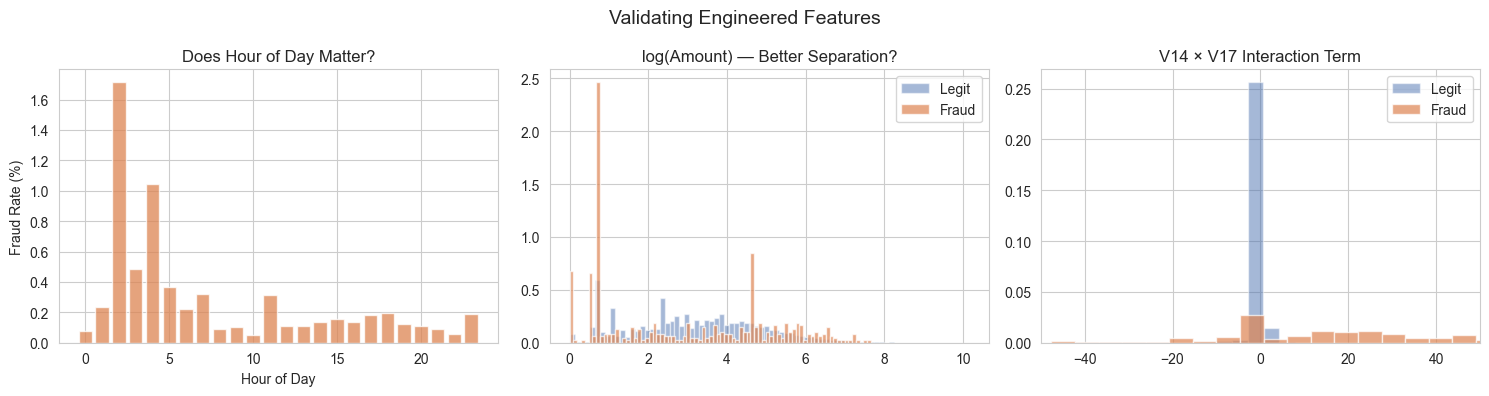

In [7]:
# Validate new features carry signals

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fraud rate by hour of day
hour_fraud = df_fe.groupby('Hour')['Class'].mean().reset_index()
axes[0].bar(hour_fraud['Hour'], hour_fraud['Class'] * 100,
            color='#DD8452', alpha=0.75)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Does Hour of Day Matter?')

# log(Amount) by class
axes[1].hist(df_fe[df_fe['Class']==0]['Amount_log'],
             bins=80, color='#4C72B0', alpha=0.5, label='Legit', density=True)
axes[1].hist(df_fe[df_fe['Class']==1]['Amount_log'],
             bins=80, color='#DD8452', alpha=0.7, label='Fraud', density=True)
axes[1].set_title('log(Amount) — Better Separation?')
axes[1].legend()

# V14 × V17 interaction term
axes[2].hist(df_fe[df_fe['Class']==0]['V14_V17'],
             bins=80, color='#4C72B0', alpha=0.5, label='Legit', density=True)
axes[2].hist(df_fe[df_fe['Class']==1]['V14_V17'],
             bins=80, color='#DD8452', alpha=0.7, label='Fraud', density=True)
axes[2].set_title('V14 × V17 Interaction Term')
axes[2].set_xlim(-50, 50)
axes[2].legend()

plt.suptitle('Validating Engineered Features', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/04_feature_validation.png', dpi=150)
plt.show()

In [8]:
# Testing Classifier Assumptions

#Class imbalance — does the severe imbalance bias the model?
#Feature scaling — do unscaled features distort distance-based models?
#Multicollinearity — are engineered features too correlated with each other?
#Data leakage — does preprocessing touch test data before the split?

# Drop raw Time and Amount — we have engineered versions
feature_cols = [c for c in df_fe.columns
                if c not in ['Class', 'Time', 'Amount']]

X = df_fe[feature_cols]
y = df_fe['Class']

# stratify=y is essential for imbalanced classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size: {X_train.shape}  |  Test size: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test  fraud rate: {y_test.mean():.4%}")
# Both should read approximately 0.1727% — stratification worked

Train size: (227845, 36)  |  Test size: (56962, 36)
Train fraud rate: 0.1729%
Test  fraud rate: 0.1720%


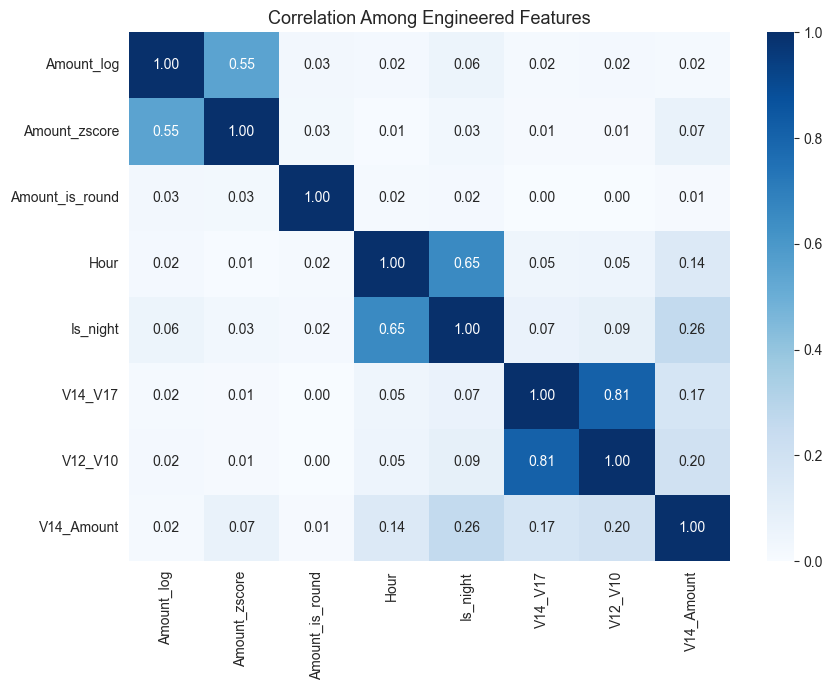

High-correlation pairs (r > 0.9): None — good to proceed


In [9]:
#Check Multicollinearity in Engineered Features

focus_cols = ['Amount_log', 'Amount_zscore', 'Amount_is_round',
              'Hour', 'Is_night', 'V14_V17', 'V12_V10', 'V14_Amount']

corr = X_train[focus_cols].corr().abs()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Correlation Among Engineered Features', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/05_correlation_heatmap.png', dpi=150)
plt.show()

# Flag any pairs with r > 0.9 — these may need one to be dropped
high_corr = [(c1, c2, round(corr.loc[c1,c2], 3))
             for c1 in corr.columns
             for c2 in corr.columns
             if c1 < c2 and corr.loc[c1,c2] > 0.9]

print("High-correlation pairs (r > 0.9):",
      high_corr if high_corr else "None — good to proceed")

In [10]:
# scale features

cols_to_scale = ['Amount_log', 'Amount_zscore', 'Hour']

# RobustScaler uses median and IQR — resistant to extreme outliers
# StandardScaler uses mean and std — can be distorted by outlier amounts
scaler = RobustScaler()

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

# RULE: fit on TRAIN only — then transform both
# Fitting on test data leaks its distribution into training
# This makes results look better than they truly are
X_train_sc[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_sc[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("Scaling applied. Scaled feature stats (train):")
print(X_train_sc[cols_to_scale].describe().round(3))

Scaling applied. Scaled feature stats (train):
       Amount_log  Amount_zscore        Hour
count  227845.000     227845.000  227845.000
mean        0.007          0.921      -0.106
std         0.670          3.490       0.648
min        -1.270         -0.306      -1.667
25%        -0.503         -0.228      -0.556
50%         0.000          0.000       0.000
75%         0.497          0.772       0.444
max         2.842        357.260       0.889


In [11]:
# Assumption Testing Summary

print("""
============================================
 CLASSIFIER ASSUMPTION CHECKS — SUMMARY
============================================

1. CLASS IMBALANCE
   Issue: 0.17% fraud rate — models default to predicting "always legit"
   Check: Class counts and fraud rate after stratified split
   Fix:   class_weight='balanced' + SMOTE (30% ratio)
   Metric to use: Average Precision (PR-AUC), not accuracy

2. FEATURE SCALING
   Issue: Amount ($0–$25,691) dwarfs V features (roughly -10 to +10)
   Check: Feature ranges compared visually
   Fix:   RobustScaler on Amount-derived features and Hour
   Note:  V1-V28 are already standardized via PCA — do not re-scale

3. MULTICOLLINEARITY
   Issue: Amount_log and Amount_zscore both derived from Amount
   Check: Correlation heatmap — flag r > 0.9 pairs
   Fix:   Drop redundant features if correlation is extreme
   Note:  Tree models (RF, XGBoost) are robust to multicollinearity;
          more critical for Logistic Regression baseline

4. DATA LEAKAGE
   Issue: Preprocessing that uses test data statistics corrupts results
   Check: All fit() calls happen on X_train only
   Fix:   Use scaler.fit_transform(X_train), scaler.transform(X_test)
          Apply SMOTE after the train/test split, never before

5. EVALUATION METRIC
   Issue: Accuracy is misleading with 0.17% fraud rate
   Correct metrics: Recall, Precision, F1, Average Precision (PR-AUC)
   Primary metric: Average Precision — penalizes models that miss fraud
============================================
""")


 CLASSIFIER ASSUMPTION CHECKS — SUMMARY

1. CLASS IMBALANCE
   Issue: 0.17% fraud rate — models default to predicting "always legit"
   Check: Class counts and fraud rate after stratified split
   Fix:   class_weight='balanced' + SMOTE (30% ratio)
   Metric to use: Average Precision (PR-AUC), not accuracy

2. FEATURE SCALING
   Issue: Amount ($0–$25,691) dwarfs V features (roughly -10 to +10)
   Check: Feature ranges compared visually
   Fix:   RobustScaler on Amount-derived features and Hour
   Note:  V1-V28 are already standardized via PCA — do not re-scale

3. MULTICOLLINEARITY
   Issue: Amount_log and Amount_zscore both derived from Amount
   Check: Correlation heatmap — flag r > 0.9 pairs
   Fix:   Drop redundant features if correlation is extreme
   Note:  Tree models (RF, XGBoost) are robust to multicollinearity;
          more critical for Logistic Regression baseline

4. DATA LEAKAGE
   Issue: Preprocessing that uses test data statistics corrupts results
   Check: All fit() c

In [ ]:
import os
import joblib

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

X_train_sc.to_csv('../data/processed/X_train_sc.csv', index=False)
X_test_sc.to_csv('../data/processed/X_test_sc.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv',        index=False)
y_test.to_csv('../data/processed/y_test.csv',          index=False)
joblib.dump(scaler, '../models/scaler.pkl')

print("All saved.")

All saved.


: 